# EnderLeaf script preparation

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Needed to import from the enderscope library

import os

os.chdir("..")

## Imports

In [3]:
import numpy as np

from enderscope.scan_patterns import snake, plot_path
from enderscope.serial import Stage
from enderscope.bed import bed

In [4]:
%matplotlib widget

## Constants

In [5]:
template_length = 210
template_size = (template_length, template_length)
row_count, col_count = 9, 9
leaf_diam = 17

## Scan Pattern

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


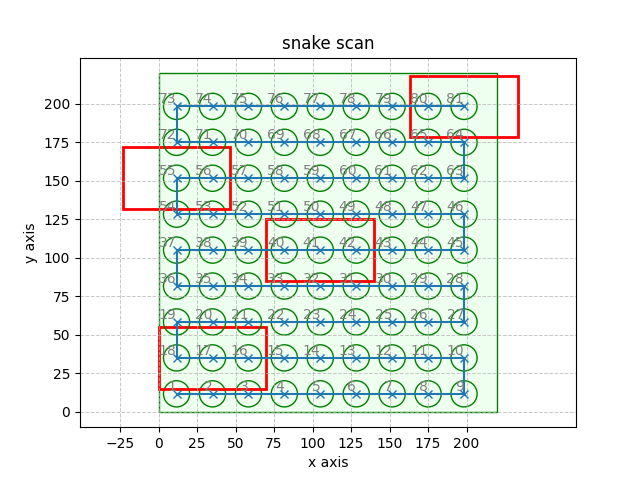

In [ ]:
positions = snake(cols=col_count, rows=row_count) * [
    # steps
    template_length / col_count,
    template_length / row_count,
] + [
    # origin
    template_length / col_count / 2, 
    template_length / row_count / 2,
]
plot_path(
    positions,
    title="snake scan",
    field=(leaf_diam + 3, leaf_diam + 3),
    selected_rectangles=[17, 41, 55, 81],
    circle_diam=leaf_diam,
)

## 3D Scan Demo

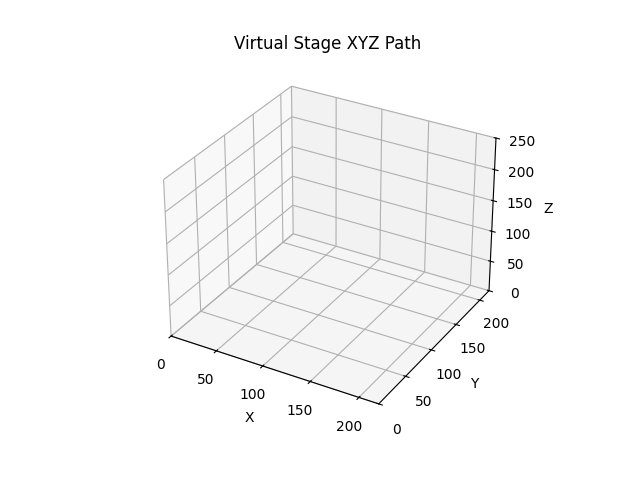

In [7]:
s = Stage('virtual', 115200)

In [8]:
s.home()

In [9]:
s.move_position((bed.x_max / 2, bed.y_max / 2, bed.global_height))
for p in positions:
    s.move_position(np.append(p, bed.individual_height))